<Axes: ylabel='time ago (generations)'>

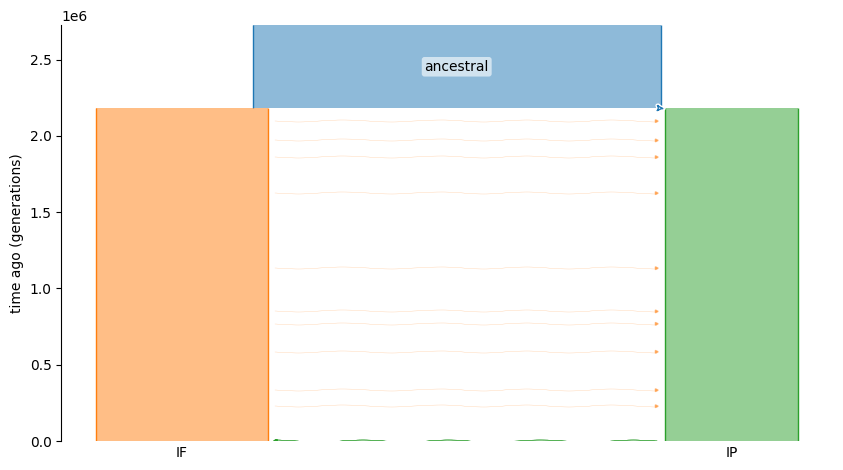

In [4]:
import demes
import demesdraw

graph = demes.load("demes.yaml")
demesdraw.tubes(graph)

In [15]:
import msprime

graph = demes.load("demes.yaml")
demography = msprime.Demography.from_demes(graph)

ts1 = msprime.sim_ancestry(samples={"IF": 2}, demography=demography, random_seed=12)
ts1 = msprime.sim_mutations(ts, rate=1e-6, random_seed=12)

ts1.dump("ts.trees")

ts2 = msprime.sim_ancestry(samples={"IF": 2}, demography=demography, random_seed=12)
ts2 = msprime.sim_mutations(ts, rate=1e-6, random_seed=12)
ts2.dump("test.trees")



In [24]:
import phlash

sample = phlash.contig("ts.trees", samples=[(0, 1)])
test = phlash.contig("test.trees", samples=[(0, 1)])

#results = phlash.fit([sample], test_data=test)

results = phlash.fit(
        data=[sample],
        mutation_rate=1e-6)

2025-06-19 10:23:47.727 | WARNING  | phlash.mcmc:_check_jax_gpu:23 - Detected that Jax is not running on GPU; you appear to have CPU-mode Jax installed. Performance may be improved by installing Jax-GPU instead. For installation instructions visit:

	https://github.com/google/jax?tab=readme-ov-file#installation

2025-06-19 10:23:47.731 | INFO     | phlash.mcmc:fit:88 - Loading data
2025-06-19 10:23:47.733 | WARNING  | phlash.data:init_mcmc_data:521 - The chunk size is 0, which is less than 10 times the overlap (500).
100%|██████████| 2.00/2.00 [00:01<00:00, 1.55bp/s]
2025-06-19 10:23:49.309 | DEBUG    | phlash.mcmc:fit:122 - Minibatch size: 1
2025-06-19 10:23:49.311 | INFO     | phlash.mcmc:fit:155 - Scaled mutation rate Θ=nan
2025-06-19 10:23:49.322 | WARNING  | phlash.kernel:get_kernel:15 - Error when loading GPU code, falling back on pure JAX implmentation. This will be **much slower**. Error was: No module named 'nvidia'


Fitting model:   0%|          | 0/1000 [00:04<?, ?it/s]


AssertionError: 